# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [26]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [34]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'

zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
csv_path = glob.glob(EXTRACT_DIR + "/*.csv")[0]

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# TODO: inspect df
df.head()

# TODO: identify target column
target = 'heart disease'

# TODO: split features and target
X = df.drop(columns=[target])
y = df[target].map({1: 0, 2: 1})

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)


### Basic visual checks

Index(['age', 'sex ', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal', 'heart disease'],
      dtype='object')


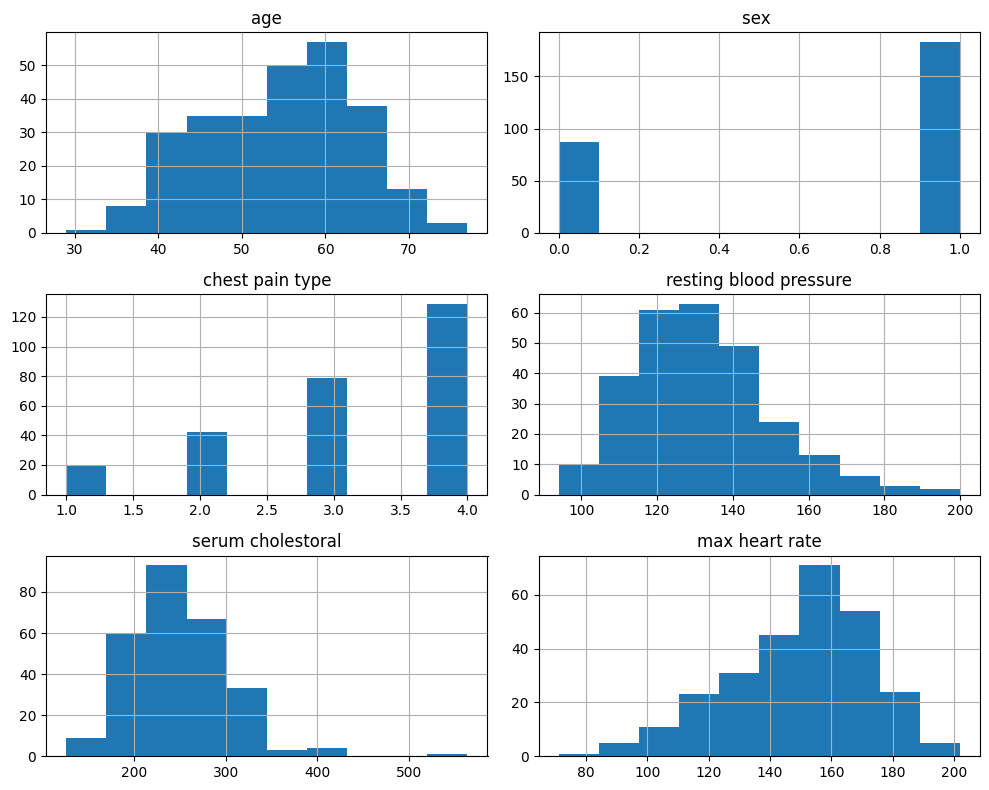

In [35]:
# TODO: pick a few numeric columns and plot histograms
print(df.columns)
num_cols = ['age', 'sex ', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'max heart rate']

# TODO: plot class balance as a bar chart
df[num_cols].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()


## Preprocessing pipeline

In [37]:
cat_cols = [
    'sex ',
    'chest pain type',
    'resting electrocardiographic results',
    'ST segment',
    'major vessels',
    'thal'
]

num_cols = [c for c in X.columns if c not in cat_cols]

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)



## Helper - evaluation function

In [38]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available."""

    # TODO: predictions
    y_pred = model.predict(X_test)

   # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    print(name, metrics)

    # TODO: confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.colorbar()
    plt.show()

   # TODO: ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)

        plt.figure()
        plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
        plt.plot([0,1],[0,1],'--')
        plt.legend()
        plt.title(f'{name} ROC')
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


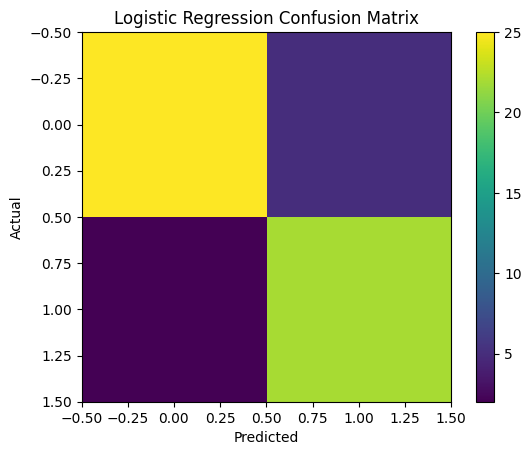

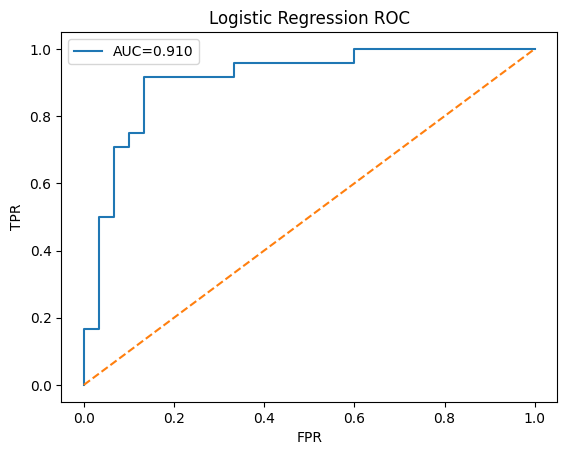

In [40]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
pipe_lr = Pipeline([
    ('preprocess', pre),
    ('model', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report("Logistic Regression", pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'model__C': 1, 'model__penalty': 'l2'}
LR grid {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


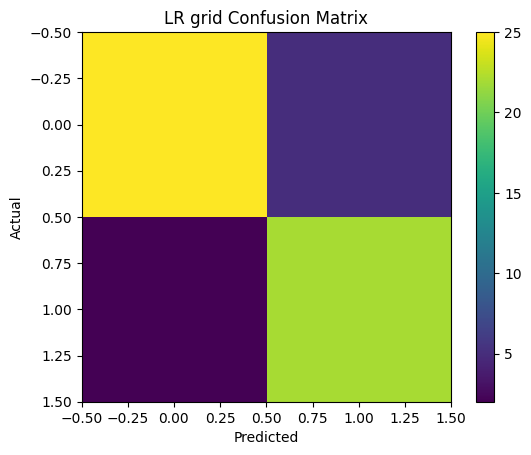

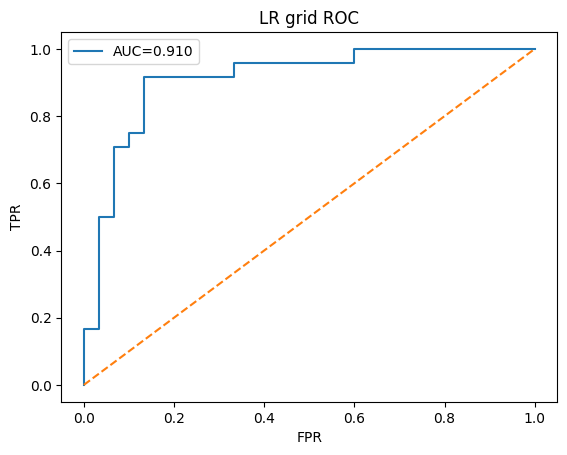

In [42]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline([
    ('preprocess', pre),
    ('model', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: define param_grid for lr__C and lr__penalty
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2']
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(
    pipe_lr_cv,
    param_grid=param_grid,
    cv=5,
    scoring='f1'
)

grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


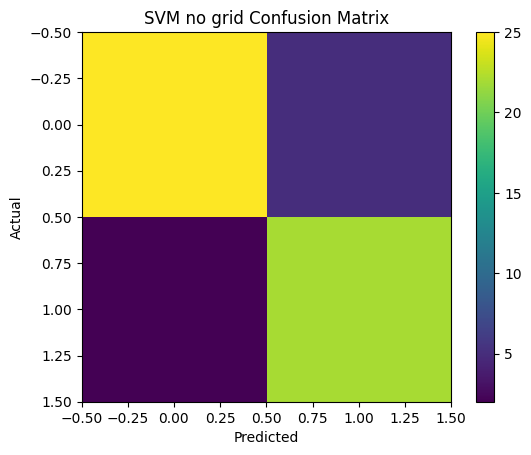

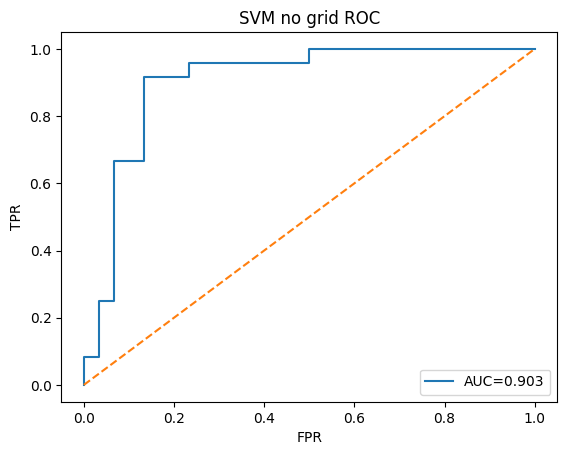

In [43]:
# TODO: choose kernel and hyperparameters for SVC
pipe_svm = Pipeline([
    ('preprocess', pre),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

pipe_svm.fit(X_train, y_train)

svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

Best params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


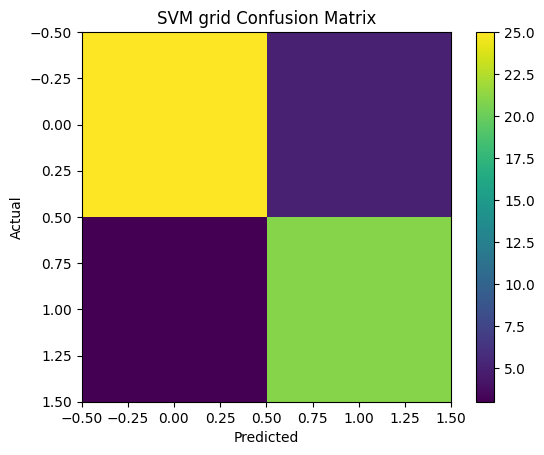

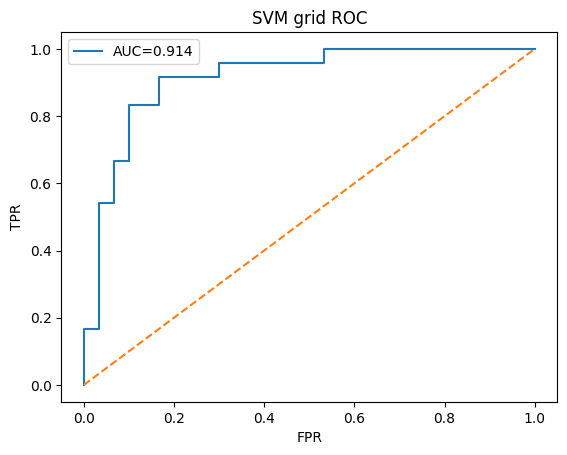

In [44]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('preprocess', pre),
    ('model', SVC(probability=True, random_state=RANDOM_STATE))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'model__kernel': ['rbf', 'linear'],
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 'auto']
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(
    pipe_svm_cv,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1'
)

grid_svm.fit(X_train, y_train)

print('Best params:', grid_svm.best_params_)

best_svm = grid_svm.best_estimator_

svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:48:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB no grid {'accuracy': 0.8333333333333334, 'precision': 0.8, 'recall': 0.8333333333333334, 'f1': 0.8163265306122449}


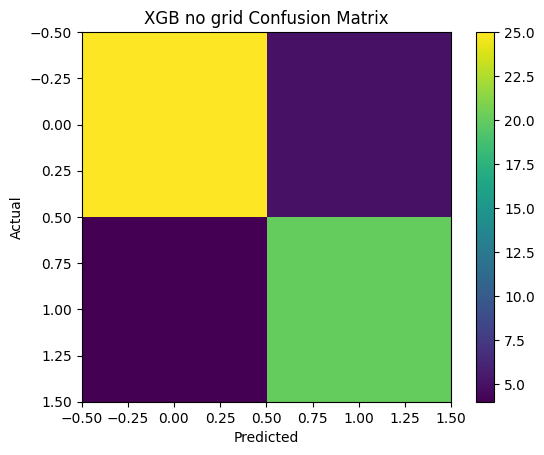

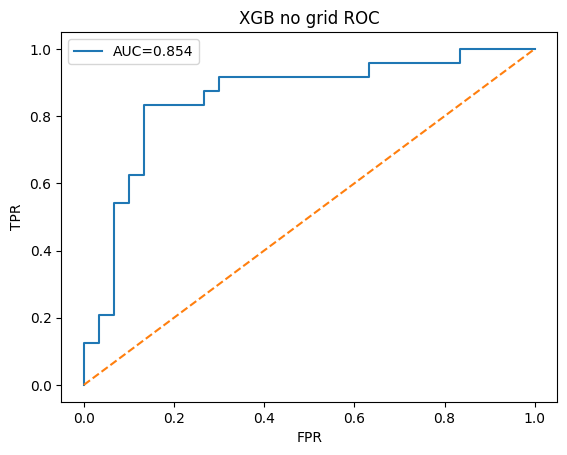

In [45]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
pipe_xgb = Pipeline([
    ('preprocess', pre),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

pipe_xgb.fit(X_train, y_train)

xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)

## Exercise 7 - XGBoost with Grid Search

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:50:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
XGB grid {'accuracy': 0.7962962962962963, 'precision': 0.7407407407407407, 'recall': 0.8333333333333334, 'f1': 0.7843137254901961}


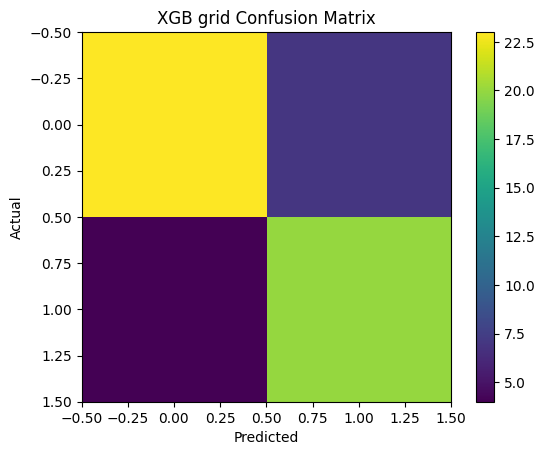

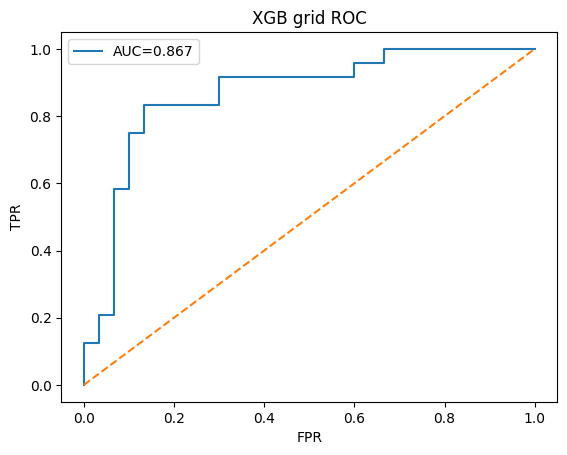

In [46]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([
    ('preprocess', pre),
    ('model', XGBClassifier(
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'model__n_estimators': [100, 300],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 4, 5],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(
    pipe_xgb_cv,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print('Best params:', grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)

## Compare models

In [50]:
# TODO: build a comparison DataFrame from your metrics dicts
summary = pd.DataFrame.from_dict({
    'LR no grid': lr_no_gs_metrics,
    'LR grid': lr_gs_metrics,
    'SVM no grid': svm_no_metrics,
    'SVM grid': svm_gs_metrics,
    'XGB no grid': xgb_no_metrics,
    'XGB grid': xgb_gs_metrics
}, orient='index')

summary = summary.round(3)
summary

,accuracy,precision,recall,f1
LR no grid,0.870,0.815,0.917,0.863
LR grid,0.870,0.815,0.917,0.863
SVM no grid,0.870,0.815,0.917,0.863
SVM grid,0.852,0.808,0.875,0.840
XGB no grid,0.833,0.800,0.833,0.816
XGB grid,0.796,0.741,0.833,0.784
